In [10]:
import numpy as np
# from PIL import Image
import taichi as ti
# import taichi_volume_renderer as tvr
import matplotlib.pyplot as plt

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


# 用单个文件测试网格转化

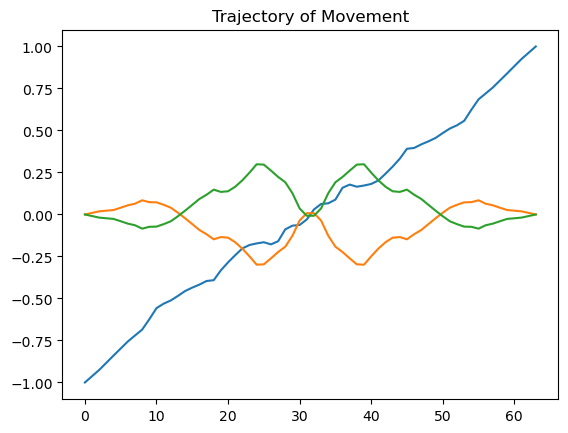

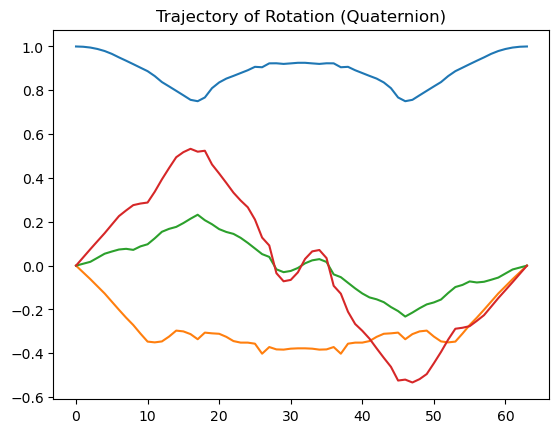

In [16]:
sofa_w = 1  # 求解域的尺寸
sofa_h = 1
sofa_d = 1

@ti.func
def is_forbidden_1(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙
    return ((x0 > 0.) ^ (x1 > 0.)) and (((y1 > 0.) ^ (z1 > 0.)) or abs(y1) > 0.5 or abs(z1) > 0.5)  # 两个正方形的孔

@ti.func
def is_forbidden_2(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙（有厚度的墙，有厚度是为了避免展示视频中出现明显的穿模）
    return (((x0 > 0.) ^ (x1 > 0.)) or abs(x1) < 0.01) and (((y1 > 0.) ^ (z1 > 0.)) or abs(y1) > 0.5 or abs(z1) > 0.5)  # 两个正方形的孔

trajectory = np.load('../trajectory/穿过两个正方形孔_17/sofa_800.npy')
xs = trajectory[:, 0]
ys = trajectory[:, 1]
zs = trajectory[:, 2]
rotations = trajectory[:, 3:]

len(xs)

plt.plot(xs, markersize=2)
plt.plot(ys, markersize=2)
plt.plot(zs, markersize=2)
plt.title('Trajectory of Movement')
plt.show()

plt.plot(rotations[:, 0], markersize=2)
plt.plot(rotations[:, 1], markersize=2)
plt.plot(rotations[:, 2], markersize=2)
plt.plot(rotations[:, 3], markersize=2)
plt.title('Trajectory of Rotation (Quaternion)')
plt.show()


In [17]:
from utils import get_sofa_3d

sofa = get_sofa_3d(is_forbidden_2, xs, ys, zs, rotations, sofa_w=sofa_w, sofa_h=sofa_h, sofa_d=sofa_d, resolution=512, trajectory_upsampling=201)

sofa.shape

(512, 512, 512)

In [18]:
from tooppy.mesh import convert_to_mesh, plot_mesh, save_mesh

# Assume you runed test_3d.py firsly, resulting in a NumPy array file result_3d.npy at ./output/.
# Now we load it, convert it to a mesh and then save it as an STL file.

mesh = convert_to_mesh(sofa, iso=0.5, sharpen_strength=0.6, smoothen_radius=2.5, upsample_factor=1)
plot_mesh(mesh)
# save_mesh(mesh, './result.stl')

# 批量转化为网格

In [ ]:
# 批量导出网格

from utils import get_sofa_3d, get_volume
from tooppy.mesh import convert_to_mesh, save_mesh
from tqdm.notebook import tqdm

sofa_w = 1  # 求解域的尺寸
sofa_h = 1
sofa_d = 1

@ti.func
def is_forbidden_1(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙
    return ((x0 > 0.) ^ (x1 > 0.)) and (((y1 > 0.) ^ (z1 > 0.)) or abs(y1) > 0.5 or abs(z1) > 0.5)  # 两个正方形的孔

@ti.func
def is_forbidden_2(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙（有厚度的墙，有厚度是为了避免展示视频中出现明显的穿模）
    return (((x0 > 0.) ^ (x1 > 0.)) or abs(x1) < 0.01) and (((y1 > 0.) ^ (z1 > 0.)) or abs(y1) > 0.5 or abs(z1) > 0.5)  # 两个正方形的孔

name = '穿过两个正方形孔_17'

volumes = []
for i in tqdm([1, 2, 202, 300, 800]):
    trajectory = np.load(f'../trajectory/{name}/sofa_{i}.npy')
    xs = trajectory[:, 0]
    ys = trajectory[:, 1]
    zs = trajectory[:, 2]
    rotations = trajectory[:, 3:]

    volume = get_volume(is_forbidden_1, xs, ys, zs, rotations, sofa_w=sofa_w, sofa_h=sofa_h, sofa_d=sofa_d, resolution=512, trajectory_upsampling=193)  # 不考虑墙厚度，用于计算体积
    volumes.append(volume)

    sofa = get_sofa_3d(is_forbidden_2, xs, ys, zs, rotations, sofa_w=sofa_w, sofa_h=sofa_h, sofa_d=sofa_d, resolution=512, trajectory_upsampling=193)  # 考虑墙厚度，用于导出在视频中不会明显穿模的网格
    mesh = convert_to_mesh(sofa, iso=0.5, sharpen_strength=0.6, smoothen_radius=2.5, upsample_factor=1)
    save_mesh(mesh, f'../meshes/{name}/{i}.stl')

volumes


  0%|          | 0/5 [00:00<?, ?it/s]

[0.5390782356262207,
 0.5979787707328796,
 0.6501376032829285,
 0.6660632491111755,
 0.6884222030639648]